In [1]:
#NIT3151 PREDICTIVE ANALYTICS ASSESSMENT 2
#Muhammad Taha - s8128767
#Justin Dang - s8149950

In [2]:
#Muhammad's Part: Steps 1-4
#Justin's Part: Steps 5-8

In [6]:
# 1. Import libraries pd(loading datatable), np(numerical operations), plt(visualization), sns(visualization)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
#show all columns and set plot style
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [7]:
# 2. Load dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

#display first few rows
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [8]:
# 3. Dataset overview
print("Shape of Dataset", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of Dataset (5110, 12)

Column names:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Data types:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

Missing values:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [9]:
#4 Business understanding

# count how many stroke and non-stroke cases exist
print("Stroke value counts:")
print(df["stroke"].value_counts())

#show the percentage distribution of the stroke variable
#helps understand class balance or imbalance
print("\nStroke class proportions:")
print(df["stroke"].value_counts(normalize=True))

Stroke value counts:
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke class proportions:
stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


In [10]:
# 5. Data gathering check

print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



Last 5 rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [11]:
# 6. Data cleaning
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
# Drop id column because it is only a unique identifier
df = df.drop(columns=["id"])

print("Columns after dropping id:")
print(df.columns.tolist())

Columns after dropping id:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [13]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [14]:
# Fill missing BMI values with mean BMI
bmiMean = df["bmi"].mean()
df["bmi"] = df["bmi"].fillna(bmiMean)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


In [15]:
# Inspect categorical variables
categoricalCols = df.select_dtypes(include="object").columns

for col in categoricalCols:
    print("\nUnique values in", col)
    print(df[col].unique())


Unique values in gender
['Male' 'Female' 'Other']

Unique values in ever_married
['Yes' 'No']

Unique values in work_type
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Unique values in Residence_type
['Urban' 'Rural']

Unique values in smoking_status
['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [16]:
# Check gender values
print(df["gender"].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


In [17]:
df = df[df["gender"] != "Other"]

print(df["gender"].value_counts())
print("New shape:", df.shape)

gender
Female    2994
Male      2115
Name: count, dtype: int64
New shape: (5109, 11)


In [18]:
# 7. Basic cleaned data summary
print("Cleaned dataset shape:")
print(df.shape)

print("\nStroke distribution:")
print(df["stroke"].value_counts())

Cleaned dataset shape:
(5109, 11)

Stroke distribution:
stroke
0    4860
1     249
Name: count, dtype: int64


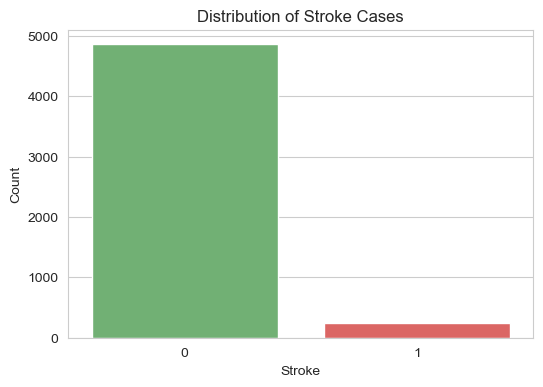

In [19]:
# 8. Stroke distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x="stroke", hue="stroke", data=df, palette={0:"#66BB6A", 1:"#EF5350"}, legend=False)
plt.title("Distribution of Stroke Cases")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

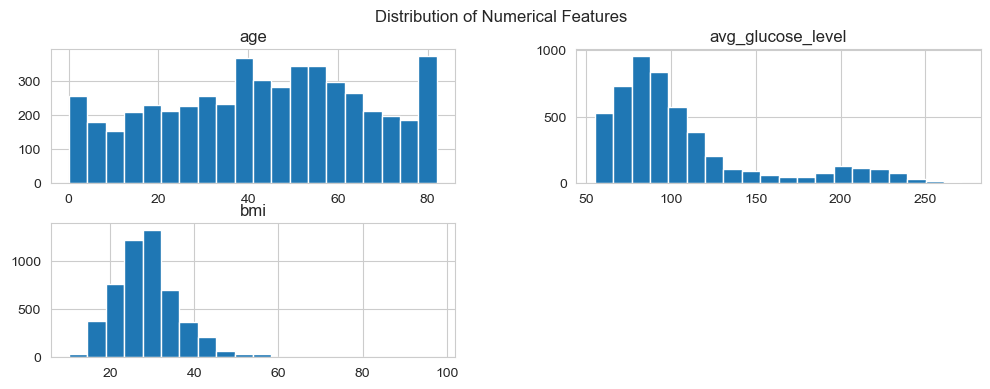

In [20]:
# 9. Numerical feature distributions
numericalCols = ["age", "avg_glucose_level", "bmi"]

df[numericalCols].hist(figsize=(12,4), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.show()

In [21]:
# 10. Boxplots of numerical features against stroke
# =========================

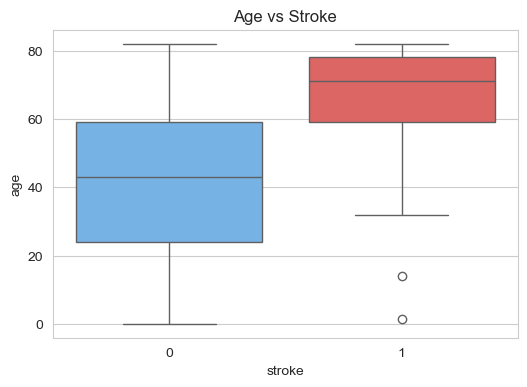

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x="stroke", y="age", hue="stroke", data=df,
            palette={0:"#64B5F6",1:"#EF5350"}, legend=False)
plt.title("Age vs Stroke")
plt.show()

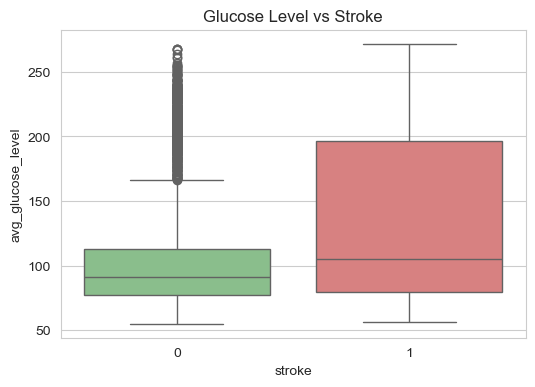

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x="stroke", y="avg_glucose_level", hue="stroke", data=df,
            palette={0:"#81C784",1:"#E57373"}, legend=False)
plt.title("Glucose Level vs Stroke")
plt.show()

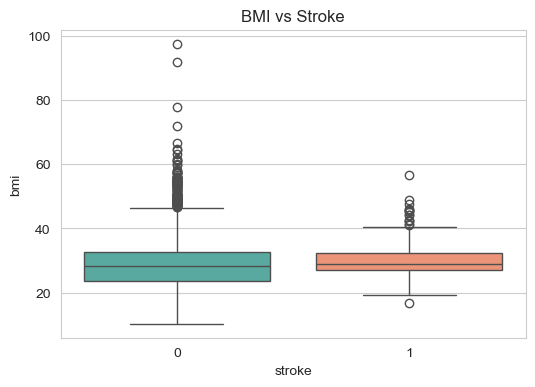

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(x="stroke", y="bmi", hue="stroke", data=df,
            palette={0:"#4DB6AC",1:"#FF8A65"}, legend=False)
plt.title("BMI vs Stroke")
plt.show()

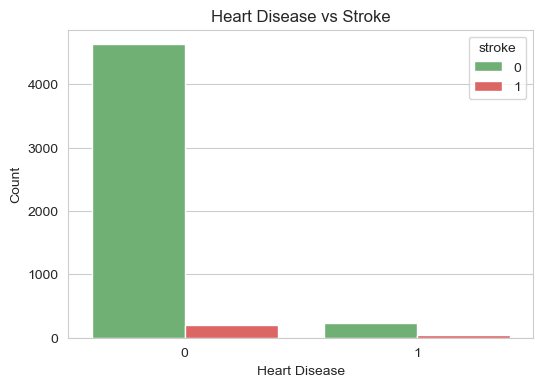

In [25]:
# Heart Disease vs Stroke
plt.figure(figsize=(6,4))
sns.countplot(x="heart_disease", hue="stroke", data=df, palette={0:"#66BB6A",1:"#EF5350"})
plt.title("Heart Disease vs Stroke")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

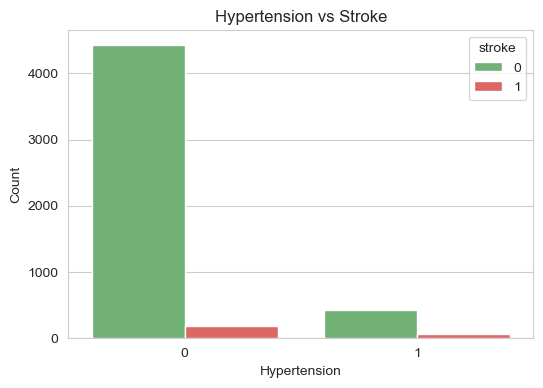

In [26]:
# Hypertension vs Stroke
plt.figure(figsize=(6,4))
sns.countplot(x="hypertension", hue="stroke", data=df, palette={0:"#66BB6A",1:"#EF5350"})
plt.title("Hypertension vs Stroke")
plt.xlabel("Hypertension")
plt.ylabel("Count")
plt.show()

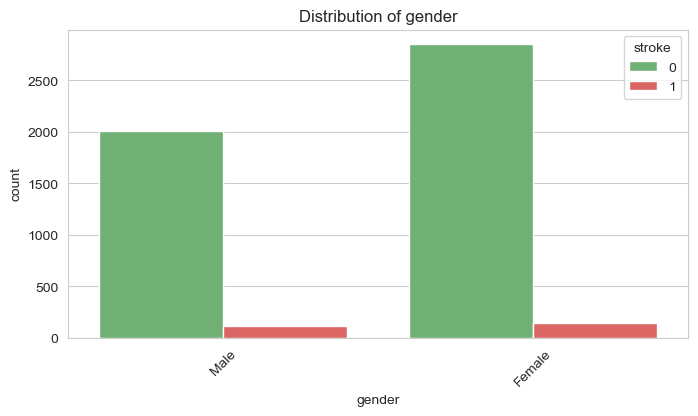

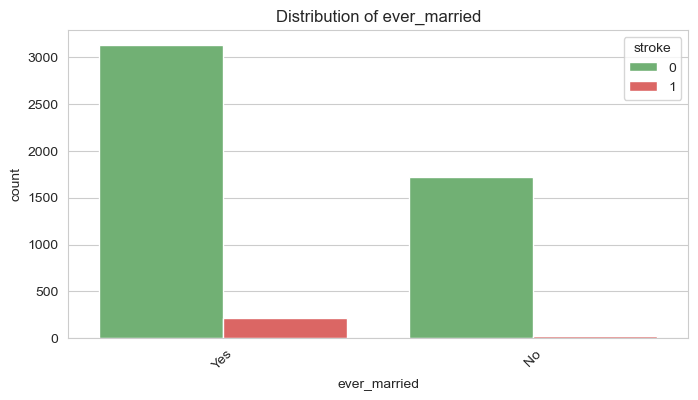

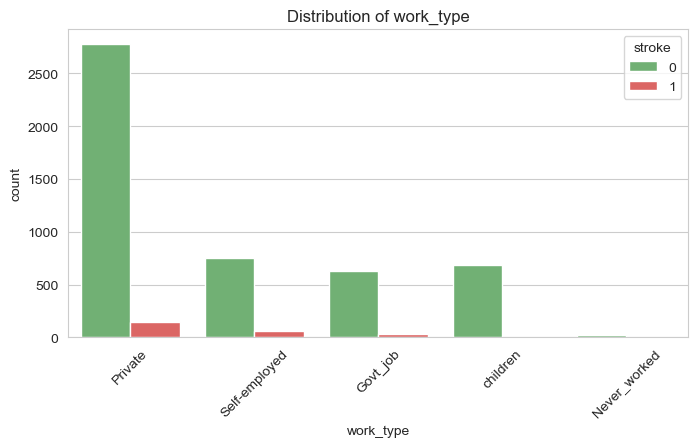

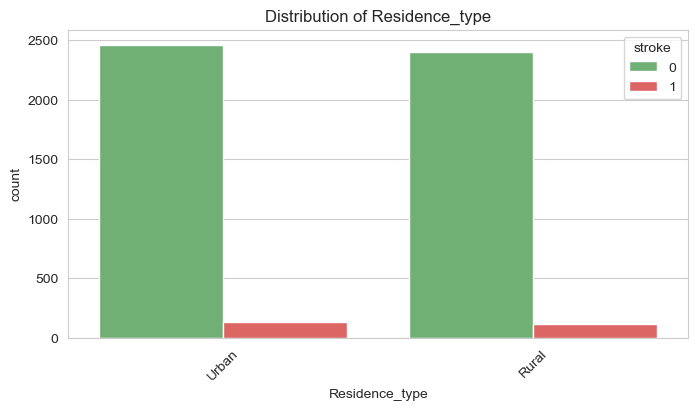

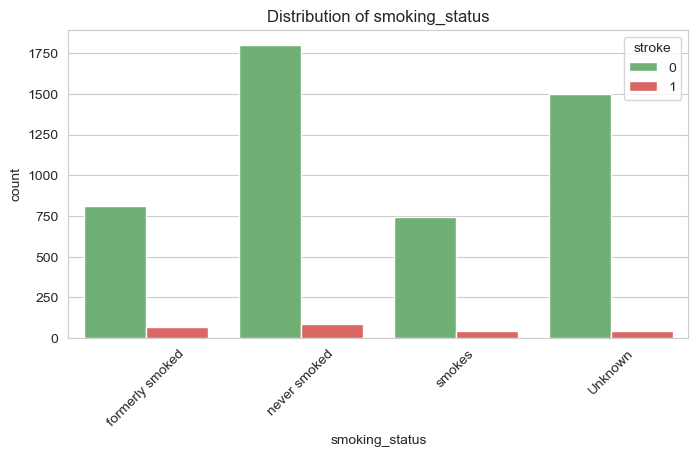

In [27]:
# 11. Categorical variable distributions
categoricalCols = ["gender","ever_married",
                   "work_type", "Residence_type", "smoking_status"]

for col in categoricalCols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue="stroke", data=df, palette={0:"#66BB6A",1:"#EF5350"})
    plt.title("Distribution of " + col)
    plt.xticks(rotation=45)
    plt.show()

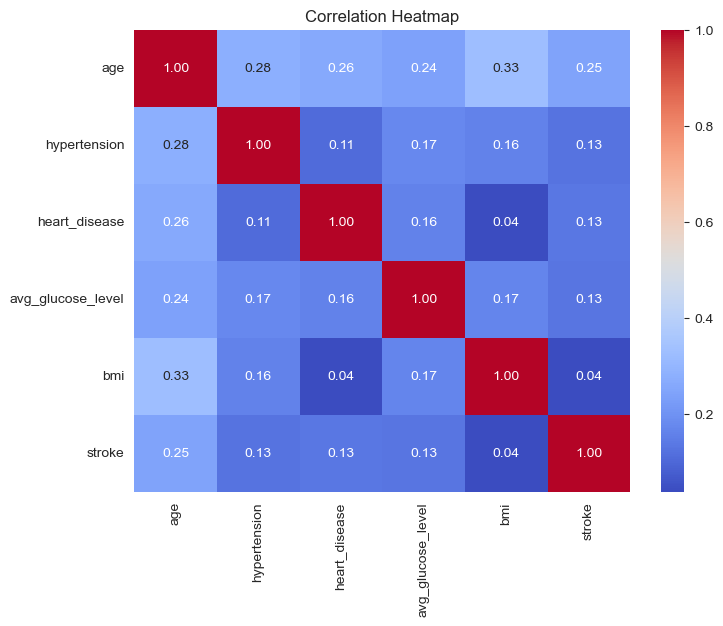

In [28]:
# 13. Correlation heatmap
numericDf = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8,6))
sns.heatmap(numericDf.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [29]:
# 14. Mean values grouped by stroke
strokeGrouped = df.groupby("stroke")[["age", "avg_glucose_level", "bmi"]].mean()
strokeGrouped

,age,avg_glucose_level,bmi
stroke,,,
0,41.974831,104.787584,28.826710
1,67.728193,132.544739,30.217789


In [30]:
# 15. Crosstab summaries
print("Hypertension vs Stroke")
display(pd.crosstab(df["hypertension"], df["stroke"], normalize="index") * 100)

print("Heart Disease vs Stroke")
display(pd.crosstab(df["heart_disease"], df["stroke"], normalize="index") * 100)

print("Ever Married vs Stroke")
display(pd.crosstab(df["ever_married"], df["stroke"], normalize="index") * 100)

print("Smoking Status vs Stroke")
display(pd.crosstab(df["smoking_status"], df["stroke"], normalize="index") * 100)

Hypertension vs Stroke


stroke,0,1
hypertension,,
0,96.031230,3.968770
1,86.746988,13.253012


Heart Disease vs Stroke


stroke,0,1
heart_disease,,
0,95.820401,4.179599
1,82.971014,17.028986


Ever Married vs Stroke


stroke,0,1
ever_married,,
No,98.348519,1.651481
Yes,93.438712,6.561288


Smoking Status vs Stroke


stroke,0,1
smoking_status,,
Unknown,96.955959,3.044041
formerly smoked,92.081448,7.918552
never smoked,95.243129,4.756871
smokes,94.676806,5.323194


In [31]:
# 16. Save cleaned dataset for partner
df.to_csv("stroke_data_cleaned.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [32]:
#Justin's Part: Steps 5-8

In [33]:
# Extra imports for Step 5-8
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

# Robust file loading so this appended section works with the uploaded file name
file_path = "healthcare-dataset-stroke-data.csv"
try:
    df_step5 = pd.read_csv(file_path)
except FileNotFoundError:
    df_step5 = pd.read_csv("healthcare-dataset-stroke-data.csv.xls")

print(df_step5.head())
print(df_step5.shape)


      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
(5110, 12)


In [34]:
# ----- Feature Engineering -----
# Keep a fresh copy so the original dataframe above is untouched
fe_df = df_step5.copy()

# Drop ID because it is only a unique identifier
fe_df = fe_df.drop(columns=['id'])

# Simple derived features based on EDA / domain understanding

# -------------------------------
# 1. Age Group Feature
# -------------------------------
# Convert continuous 'age' into categorical groups.
# This helps the model capture non-linear relationships between age and stroke risk,
# as risk may increase differently across life stages rather than linearly.
# The bins are based on general life stages (childhood → elderly).
fe_df['age_group'] = pd.cut(
    fe_df['age'],
    bins=[0, 18, 40, 60, 80, 120],
    labels=['Child', 'Young Adult', 'Middle Age', 'Senior', 'Elderly'],
    include_lowest=True
)

# -------------------------------
# 2. Glucose Risk Level
# -------------------------------
# Categorize average glucose level into medically meaningful risk groups.
# These thresholds are inspired by common clinical interpretations:
# - Normal (<100)
# - Prediabetes (100–140)
# - High (140–200)
# - Very High (>200)
# This helps the model better distinguish health risk levels instead of treating glucose as purely numeric.
fe_df['glucose_risk'] = pd.cut(
    fe_df['avg_glucose_level'],
    bins=[0, 100, 140, 200, np.inf],
    labels=['Normal', 'Prediabetes', 'High', 'Very High'],
    include_lowest=True
)

# -------------------------------
# 3. BMI Category
# -------------------------------
# Convert BMI into standard health categories based on WHO guidelines:
# - Underweight (<18.5)
# - Normal (18.5–25)
# - Overweight (25–30)
# - Obese (>30)
# This improves interpretability and allows the model to capture risk patterns
# associated with obesity rather than relying on raw BMI values.
# BMI category based on common health interpretation
fe_df['bmi_category'] = pd.cut(
    fe_df['bmi'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese'],
    include_lowest=True
)

# High-risk combination feature
fe_df['cardio_risk_flag'] = ((fe_df['hypertension'] == 1) | (fe_df['heart_disease'] == 1)).astype(int)

print(fe_df[['age', 'age_group', 'avg_glucose_level', 'glucose_risk', 'bmi', 'bmi_category', 'cardio_risk_flag']].head())


    age   age_group  avg_glucose_level glucose_risk   bmi bmi_category  \
0  67.0      Senior             228.69    Very High  36.6        Obese   
1  61.0      Senior             202.21    Very High   NaN          NaN   
2  80.0      Senior             105.92  Prediabetes  32.5        Obese   
3  49.0  Middle Age             171.23         High  34.4        Obese   
4  79.0      Senior             174.12         High  24.0       Normal   

   cardio_risk_flag  
0                 1  
1                 0  
2                 1  
3                 0  
4                 1  


In [35]:
# Split features and target
X = fe_df.drop(columns=['stroke'])
y = fe_df['stroke']

# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Stroke distribution in y_train:')
print(y_train.value_counts(normalize=True))


Numeric features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categorical features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'age_group', 'glucose_risk', 'bmi_category']
X_train shape: (4088, 14)
X_test shape: (1022, 14)
Stroke distribution in y_train:
stroke
0    0.951321
1    0.048679
Name: proportion, dtype: float64


In [49]:

# ----- Predictive Modell Training (Logistic Regression, Decision Tree, Random Forest, SVM and KNN) and Evaluation -----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_configs = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__solver': ['liblinear', 'lbfgs']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(class_weight='balanced', random_state=42),
        'params': {
            'model__max_depth': [3, 5, 10, None],
            'model__min_samples_split': [2, 10, 20],
            'model__min_samples_leaf': [1, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [5, 10, None],
            'model__min_samples_split': [2, 10]
        }
    },
    'SVM': {
        'model': SVC(class_weight='balanced', probability=True, random_state=42),
        'params': {
            'model__C': [0.5, 1, 5],
            'model__kernel': ['linear', 'rbf'],
            'model__gamma': ['scale', 'auto']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': [3, 5, 7, 11],
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['minkowski']
        }
    }
}

results = []
best_models = {}

for model_name, config in model_configs.items():
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', config['model'])
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=config['params'],
        scoring='recall',
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    # Probability scores for ROC-AUC where possible
    if hasattr(best_model, 'predict_proba'):
        y_prob = best_model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    result_row = {
        'Model': model_name,
        'Best Params': grid.best_params_,
        'CV F1': grid.best_score_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    }

    results.append(result_row)
    best_models[model_name] = best_model

    print(f"\n{'='*70}")
    print(f"{model_name}")
    print(f"Best Parameters: {grid.best_params_}")
    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results).sort_values(by='Recall', ascending=False).reset_index(drop=True)
results_df



Logistic Regression
Best Parameters: {'model__C': 0.1, 'model__solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.14      0.82      0.24        50

    accuracy                           0.74      1022
   macro avg       0.56      0.78      0.54      1022
weighted avg       0.95      0.74      0.81      1022


Decision Tree
Best Parameters: {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.99      0.66      0.79       972
           1       0.11      0.82      0.19        50

    accuracy                           0.66      1022
   macro avg       0.55      0.74      0.49      1022
weighted avg       0.94      0.66      0.76      1022


Random Forest
Best Parameters: {'model__max_depth': 5, 'model__min_samples_split': 10, 'model__n_estimators': 200}
              precision    

,Model,Best Params,CV F1,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,"{'model__C': 0.1, 'model__solver': 'liblinear'}",0.819231,0.739726,0.137584,0.82,0.235632,0.835535
1,Decision Tree,"{'model__max_depth': 3, 'model__min_samples_le...",0.833974,0.664384,0.109333,0.82,0.192941,0.784300
2,SVM,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.814231,0.731898,0.131579,0.80,0.225989,0.837366
3,Random Forest,"{'model__max_depth': 5, 'model__min_samples_sp...",0.683974,0.756360,0.135531,0.74,0.229102,0.809239
4,KNN,"{'model__metric': 'minkowski', 'model__n_neigh...",0.592821,0.737769,0.107914,0.60,0.182927,0.735885


In [50]:

# Show a cleaner summary table for the report
summary_table = results_df.copy()
metric_columns = ['CV F1', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
summary_table[metric_columns] = summary_table[metric_columns].round(4)
summary_table


,Model,Best Params,CV F1,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,"{'model__C': 0.1, 'model__solver': 'liblinear'}",0.8192,0.7397,0.1376,0.82,0.2356,0.8355
1,Decision Tree,"{'model__max_depth': 3, 'model__min_samples_le...",0.8340,0.6644,0.1093,0.82,0.1929,0.7843
2,SVM,"{'model__C': 1, 'model__gamma': 'scale', 'mode...",0.8142,0.7319,0.1316,0.80,0.2260,0.8374
3,Random Forest,"{'model__max_depth': 5, 'model__min_samples_sp...",0.6840,0.7564,0.1355,0.74,0.2291,0.8092
4,KNN,"{'model__metric': 'minkowski', 'model__n_neigh...",0.5928,0.7378,0.1079,0.60,0.1829,0.7359


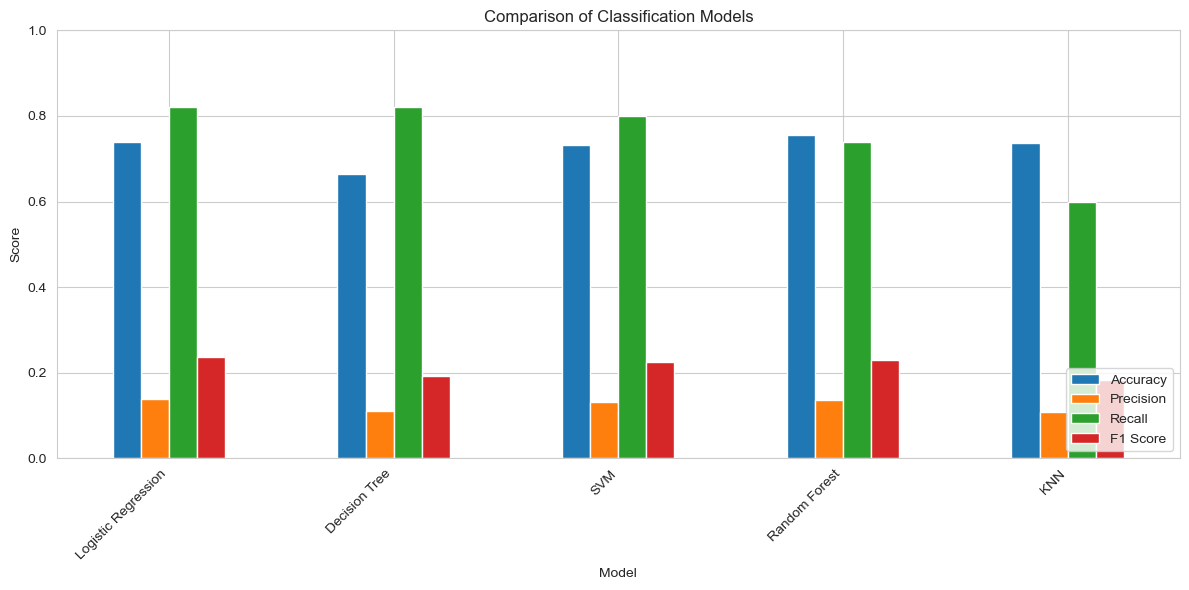

In [51]:

# ----- Step 7: Data Visualisation -----
plot_df = summary_table.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']]
plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Comparison of Classification Models')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


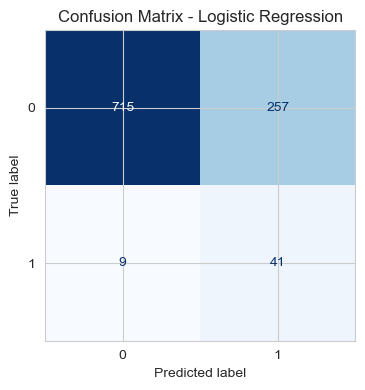

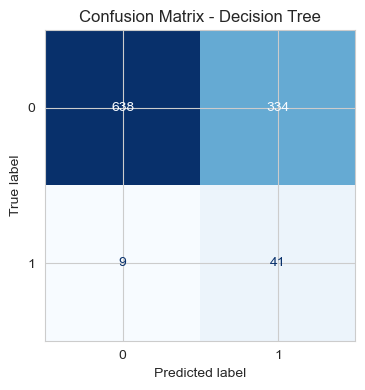

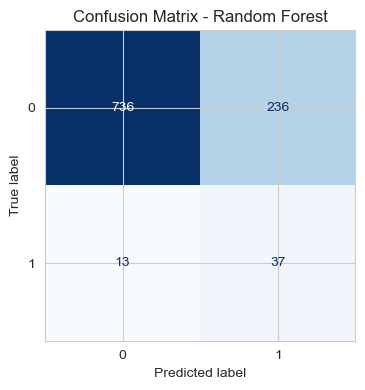

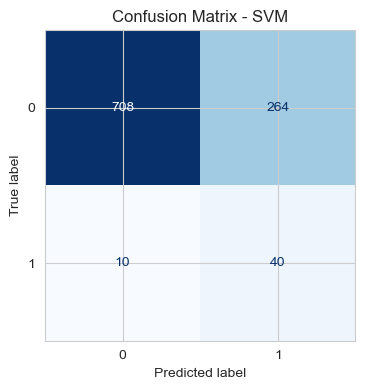

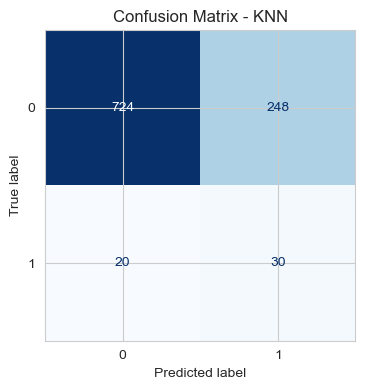

In [52]:

# Confusion matrices for all tuned models
for model_name, model in best_models.items():
    y_pred = model.predict(X_test)
    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax, colorbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()


In [53]:

# Optional: highlight the best model based on F1 score
best_model_row = summary_table.sort_values(by='Recall', ascending=False).iloc[0]
print('Recommended model based on test-set Recall:')
print(best_model_row[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Best Params']])


Recommended model based on test-set Recall:
Model                                      Logistic Regression
Accuracy                                                0.7397
Precision                                               0.1376
Recall                                                    0.82
F1 Score                                                0.2356
ROC AUC                                                 0.8355
Best Params    {'model__C': 0.1, 'model__solver': 'liblinear'}
Name: 0, dtype: object
